In [33]:
import pandas as pd
df = pd.read_csv("Tweets.csv")  # o como se llame el archivo descargado
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


<Axes: xlabel='airline_sentiment'>

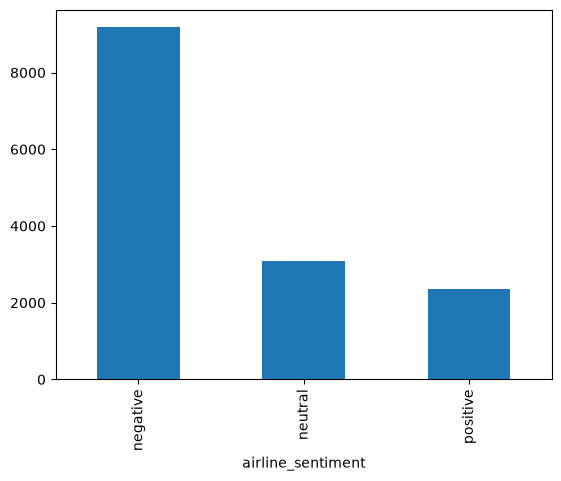

In [34]:
df['airline_sentiment'].value_counts().plot(kind='bar')

In [35]:
df.count()

tweet_id                        14640
airline_sentiment               14640
airline_sentiment_confidence    14640
negativereason                   9178
negativereason_confidence       10522
airline                         14640
airline_sentiment_gold             40
name                            14640
negativereason_gold                32
retweet_count                   14640
text                            14640
tweet_coord                      1019
tweet_created                   14640
tweet_location                   9907
user_timezone                    9820
dtype: int64

In [36]:
import re


def clean_for_tfidf(text: str) -> str:
    """Limpieza agresiva: para TF-IDF + Logistic Regression."""
    text = re.sub(r'@\w+', '', text)              # menciones
    text = re.sub(r'http\S+', '', text)            # URLs
    text = text.lower()                             # minúsculas
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)     # quita puntuación/emojis
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def clean_for_transformer(text: str) -> str:
    """Limpieza mínima: para RoBERTa u otro transformer."""
    text = re.sub(r'@\w+', '@user', text)           # normaliza menciones (así entrenó cardiffnlp)
    text = re.sub(r'http\S+', 'http', text)         # normaliza URLs
    text = re.sub(r'\s+', ' ', text).strip()
    # se conservan mayúsculas, signos de puntuación y emojis a propósito
    return text

In [37]:
df['airline_sentiment'].isnull().sum()  # para ver si hay valores nulos en la columna de sentimientos

np.int64(0)

In [38]:
df['text'].isnull().sum()  # para ver si hay valores nulos en la columna de texto

np.int64(0)

In [39]:
df_model = df[['text', 'airline_sentiment']].copy()


In [40]:
df_model['text_clean_tfidf'] = df_model['text'].apply(clean_for_tfidf)
df_model['text_clean_transformer'] = df_model['text'].apply(clean_for_transformer)

In [41]:
df_model.head()

,text,airline_sentiment,text_clean_tfidf,text_clean_transformer
0,@VirginAmerica What @dhepburn said.,neutral,what said,@user What @user said.
1,@VirginAmerica plus you've added commercials t...,positive,plus youve added commercials to the experience...,@user plus you've added commercials to the exp...
2,@VirginAmerica I didn't today... Must mean I n...,neutral,i didnt today must mean i need to take another...,@user I didn't today... Must mean I need to ta...
3,@VirginAmerica it's really aggressive to blast...,negative,its really aggressive to blast obnoxious enter...,@user it's really aggressive to blast obnoxiou...
4,@VirginAmerica and it's a really big bad thing...,negative,and its a really big bad thing about it,@user and it's a really big bad thing about it


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
# Split por índices (reemplaza tu celda de split anterior)
train_idx, test_idx = train_test_split(
    df_model.index,
    test_size=0.2,
    random_state=42,
    stratify=df_model['airline_sentiment']
)

train_df = df_model.loc[train_idx]
test_df = df_model.loc[test_idx]

y_train = train_df['airline_sentiment']
y_test = test_df['airline_sentiment']

In [57]:
train_idx, test_idx = train_test_split(
    df_model.index,
    test_size=0.2,
    random_state=42,
    stratify=df_model['airline_sentiment']
)

train_df = df_model.loc[train_idx]
test_df = df_model.loc[test_idx]

y_train = train_df['airline_sentiment']
y_test = test_df['airline_sentiment']

In [58]:
X_train = train_df['text_clean_tfidf']
X_test = test_df['text_clean_tfidf']

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['negative','neutral','positive']"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None


In [59]:
preds = pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, preds):.3f}")
print(f"F1 macro: {f1_score(y_test, preds, average='macro'):.3f}")
print(classification_report(y_test, preds))

Accuracy: 0.773
F1 macro: 0.728
              precision    recall  f1-score   support

    negative       0.89      0.81      0.85      1835
     neutral       0.57      0.71      0.63       620
    positive       0.69      0.72      0.71       473

    accuracy                           0.77      2928
   macro avg       0.72      0.75      0.73      2928
weighted avg       0.79      0.77      0.78      2928



In [60]:
X_test_transformer = test_df['text_clean_transformer']

resultados = sentiment_model(list(X_test_transformer), batch_size=64, truncation=True)
predicciones = [label_map[r["label"]] for r in resultados]

print(f"Accuracy: {accuracy_score(y_test, predicciones):.3f}")
print(f"F1 macro: {f1_score(y_test, predicciones, average='macro'):.3f}")
print(classification_report(y_test, predicciones))

Accuracy: 0.735
F1 macro: 0.708
              precision    recall  f1-score   support

    negative       0.94      0.71      0.81      1835
     neutral       0.48      0.70      0.57       620
    positive       0.66      0.88      0.75       473

    accuracy                           0.73      2928
   macro avg       0.69      0.76      0.71      2928
weighted avg       0.79      0.73      0.75      2928



In [61]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

dummy_accuracy = accuracy_score(y_test, dummy_preds)
dummy_f1_macro = f1_score(y_test, dummy_preds, average="macro")

print(f"Dummy accuracy: {dummy_accuracy:.3f}")
print(f"Dummy F1 macro: {dummy_f1_macro:.3f}")

Dummy accuracy: 0.627
Dummy F1 macro: 0.257


In [62]:
import pandas as pd

comparacion = pd.DataFrame({
    "Modelo": ["Dummy (baseline)", "TF-IDF + LogReg", "RoBERTa (zero-shot)"],
    "Accuracy": [dummy_accuracy, accuracy, accuracy_score(y_test, predicciones)],
    "F1 macro": [dummy_f1_macro, f1_macro, f1_score(y_test, predicciones, average="macro")]
})

comparacion

,Modelo,Accuracy,F1 macro
0,Dummy (baseline),0.626708,0.256841
1,TF-IDF + LogReg,0.773224,0.728351
2,RoBERTa (zero-shot),0.734973,0.708407


<Axes: xlabel='Modelo'>

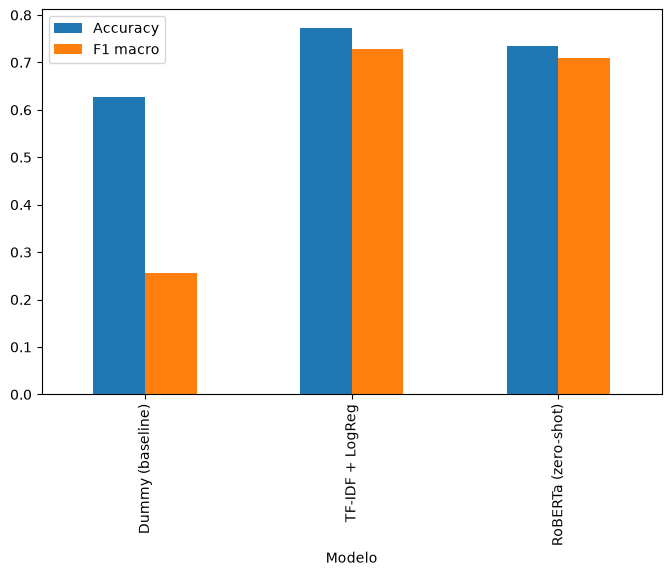

In [63]:
comparacion.plot(x="Modelo", y=["Accuracy", "F1 macro"], kind="bar", figsize=(8, 5))

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

train_dataset = Dataset.from_dict({
    "text": train_df["text_clean_transformer"].tolist(),
    "label": train_df["airline_sentiment"].map(label2id).tolist(),
})
test_dataset = Dataset.from_dict({
    "text": test_df["text_clean_transformer"].tolist(),
    "label": test_df["airline_sentiment"].map(label2id).tolist(),
})

In [ ]:
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

In [ ]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

training_args = TrainingArguments(
    output_dir="./roberta_finetuned",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

In [ ]:
# trainer.save_model("./roberta_finetuned_final")
# tokenizer.save_pretrained("./roberta_finetuned_final")

In [ ]:
predictions = trainer.predict(test_dataset)
preds_finetuned = np.argmax(predictions.predictions, axis=1)

preds_finetuned_labels = [id2label[p] for p in preds_finetuned]
y_test_labels = [id2label[int(l)] for l in test_dataset["label"]]

from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

cm = confusion_matrix(y_test_labels, preds_finetuned_labels, labels=["negative", "neutral", "positive"])
cm_df = pd.DataFrame(cm, 
    index=["real: negative", "real: neutral", "real: positive"],
    columns=["pred: negative", "pred: neutral", "pred: positive"])
print(cm_df)
print()
print(classification_report(y_test_labels, preds_finetuned_labels))

In [5]:
huggingface-cli login

SyntaxError: invalid syntax (1355118443.py, line 1)

In [ ]:
""" from huggingface_hub import login
from transformers import AutoModelForSequenceClassification, AutoTokenizer

login()  # te pide tu token de Hugging Face (con permiso de escritura)

model = AutoModelForSequenceClassification.from_pretrained("../roberta_finetuned_final")
tokenizer = AutoTokenizer.from_pretrained("../roberta_finetuned_final")

model.push_to_hub("cesarrf/roberta-airline-sentiment")
tokenizer.push_to_hub("cesarrf/roberta-airline-sentiment") """

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:04<00:00,  4.78s/it]
Processing Files (1 / 1): 100%|██████████|  499MB /  499MB, 11.1MB/s  
New Data Upload: 100%|██████████|  499MB /  499MB, 11.1MB/s  
d:\sentimientos_tickets\ticket_airline\venv_tf\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\home\.cache\huggingface\hub\models--cesarrf--roberta-airline-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https:

CommitInfo(commit_url='https://huggingface.co/cesarrf/roberta-airline-sentiment/commit/2e251839bfadec3579b839593e9c877dd6917672', commit_message='Upload tokenizer', commit_description='', oid='2e251839bfadec3579b839593e9c877dd6917672', pr_url=None, repo_url=RepoUrl('https://huggingface.co/cesarrf/roberta-airline-sentiment', endpoint='https://huggingface.co', repo_type='model', repo_id='cesarrf/roberta-airline-sentiment'), pr_revision=None, pr_num=None)